# Estudo de caso 1 - Previsão de Preço de Ações

Features comumente uteis para a previsão do preço das são estes

1. Ativos correlacionados
    * Uma organização depende de e interage com muito fatores externos, incluindo concorrentes, clientes, e economia global, a situação geopolitica, politicas fiscais e monetarias, acesso ao capital e assim por diante.
2. Indicadores tecnicos
    * Media movel, media movel exponencial e momentum
3. Analise fundementalista
4. Relatorio de desempenho
    * Relatorio anuais a trimestrais das empresas podem ser usadas para extrair ou determinar metricas-chave como ROE

5. Noticias

### Carregando dados e pacotes python

In [7]:
from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    ElasticNet
)

from sklearn.tree      import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm       import SVR

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)

from sklearn.neural_network import MLPRegressor

# Para analise de dados e a avaliacao de modelos
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV,
)

from sklearn.feature_selection import (
    SelectKBest,
    chi2, f_regression
)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sktime.regression.interval_based import TimeSeriesForestRegressor

# RNA
import tensorflow as tf
import keras

Mais pacotes...

In [8]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web

import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from pandas.plotting import scatter_matrix
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima_model import ARIMA
import yfinance as yf

Carregando dados

In [9]:
stk_tickers = ['MSFT', 'IBM', 'GOOGL']
ccy_tickers = ['DEXJPUS', 'DEXUSUK']
idx_tickers = ['SP500', 'DJIA', 'VIXCLS']

In [10]:
stk_data = yf.download(stk_tickers, start='2015-01-01', auto_adjust=True)
ccy_data = web.DataReader(ccy_tickers, 'fred', start='2015-01-01')
idx_data = web.DataReader(idx_tickers, 'fred', start='2015-01-01')

[*********************100%***********************]  3 of 3 completed


> A target é o retorno semanal da ação da microsoft. Presume-se que o numero de dias uteuis para negociação por semana é cinco, e computamos o retorno usando esse parametro.


> As features são retornos defasados  dos cincos dias das ações, moedas e indices.

In [11]:
stk_data.shape, ccy_data.shape, idx_data.shape

((2676, 15), (2772, 2), (2777, 3))

In [12]:
period = 5

In [13]:
Y = stk_data.loc[:, ('Close','MSFT')].apply(lambda x: np.log(x)).diff(period).shift(-period)

In [14]:
Y.name = 'MSFT_pred'

In [15]:
X1 = stk_data.loc[:, ('Close',('IBM', 'GOOGL'))].apply(lambda x: np.log(x)).diff(period)

In [16]:
X1.columns = X1.columns.droplevel()

In [17]:
X1

Ticker,IBM,GOOGL
Date,,
2015-01-02,NaN,NaN
2015-01-05,NaN,NaN
2015-01-06,NaN,NaN
2015-01-07,NaN,NaN
2015-01-08,NaN,NaN
...,...,...
2025-08-18,0.013242,0.012361
2025-08-19,0.027352,-0.008743
2025-08-20,0.010277,-0.013158


In [18]:
X2 = ccy_data.loc[:, ('DEXJPUS', 'DEXUSUK')].apply(lambda x: np.log(x)).diff(period)
X3 = idx_data.loc[:, ('SP500', 'DJIA', 'VIXCLS')].apply(lambda x: np.log(x)).diff(period)

In [19]:
X4 = pd.concat([
    np.log(stk_data.loc[:, ('Close', 'MSFT')]).diff(i) \
    for i in [period, period*3, period*6, period*12]
], axis=1).dropna()

In [20]:
X4.columns = ['MSFT_DT', 'MSFT_DT3', 'MSFT_DT6', 'MSFT_DT12']

In [21]:
X = pd.concat([X1, X2, X3, X4], axis=1)

In [22]:
data = pd.concat([Y, X], axis=1).dropna().iloc[::period,:]

In [23]:
Y = data.loc[:, ~data.columns.isin(X.columns)]
X = data.loc[:, X.columns]

Analise dos dados

In [24]:
data.tail()

,MSFT_pred,IBM,GOOGL,DEXJPUS,DEXUSUK,SP500,DJIA,VIXCLS,MSFT_DT,MSFT_DT3,MSFT_DT6,MSFT_DT12
2025-07-14,0.013898,-0.030128,0.026624,0.012468,-0.014848,0.006174,0.001199,-0.033727,0.010592,0.052275,0.092277,0.267326
2025-07-21,0.004772,0.003237,0.045964,-0.002848,0.004529,0.005891,-0.003077,-0.032499,0.013898,0.028073,0.086744,0.311064
2025-07-28,0.044162,-0.078519,0.012961,0.007981,-0.007809,0.013260,0.011541,-0.102362,0.004772,0.029263,0.067872,0.261591
2025-08-04,-0.026235,-0.043602,0.012693,-0.009204,-0.007720,-0.009408,-0.014918,0.153295,0.044162,0.062832,0.115108,0.213751
2025-08-11,-0.008991,-0.057509,0.030100,0.006100,0.009287,0.006850,-0.004505,-0.075250,-0.026235,0.022699,0.050772,0.143301


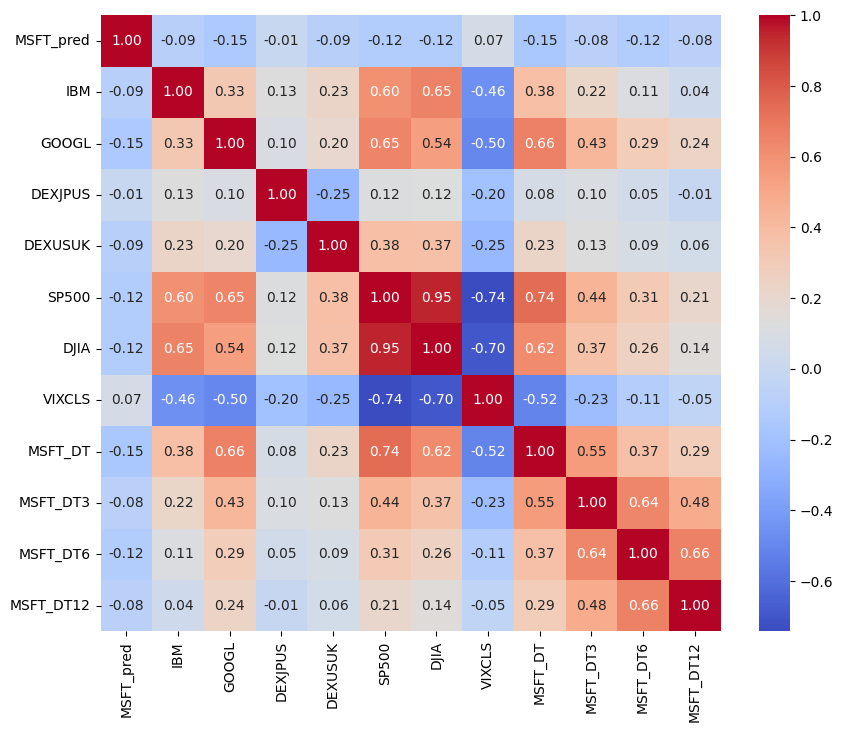

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

Agora iremos visualizar todas a variaveis na regressão usadas 

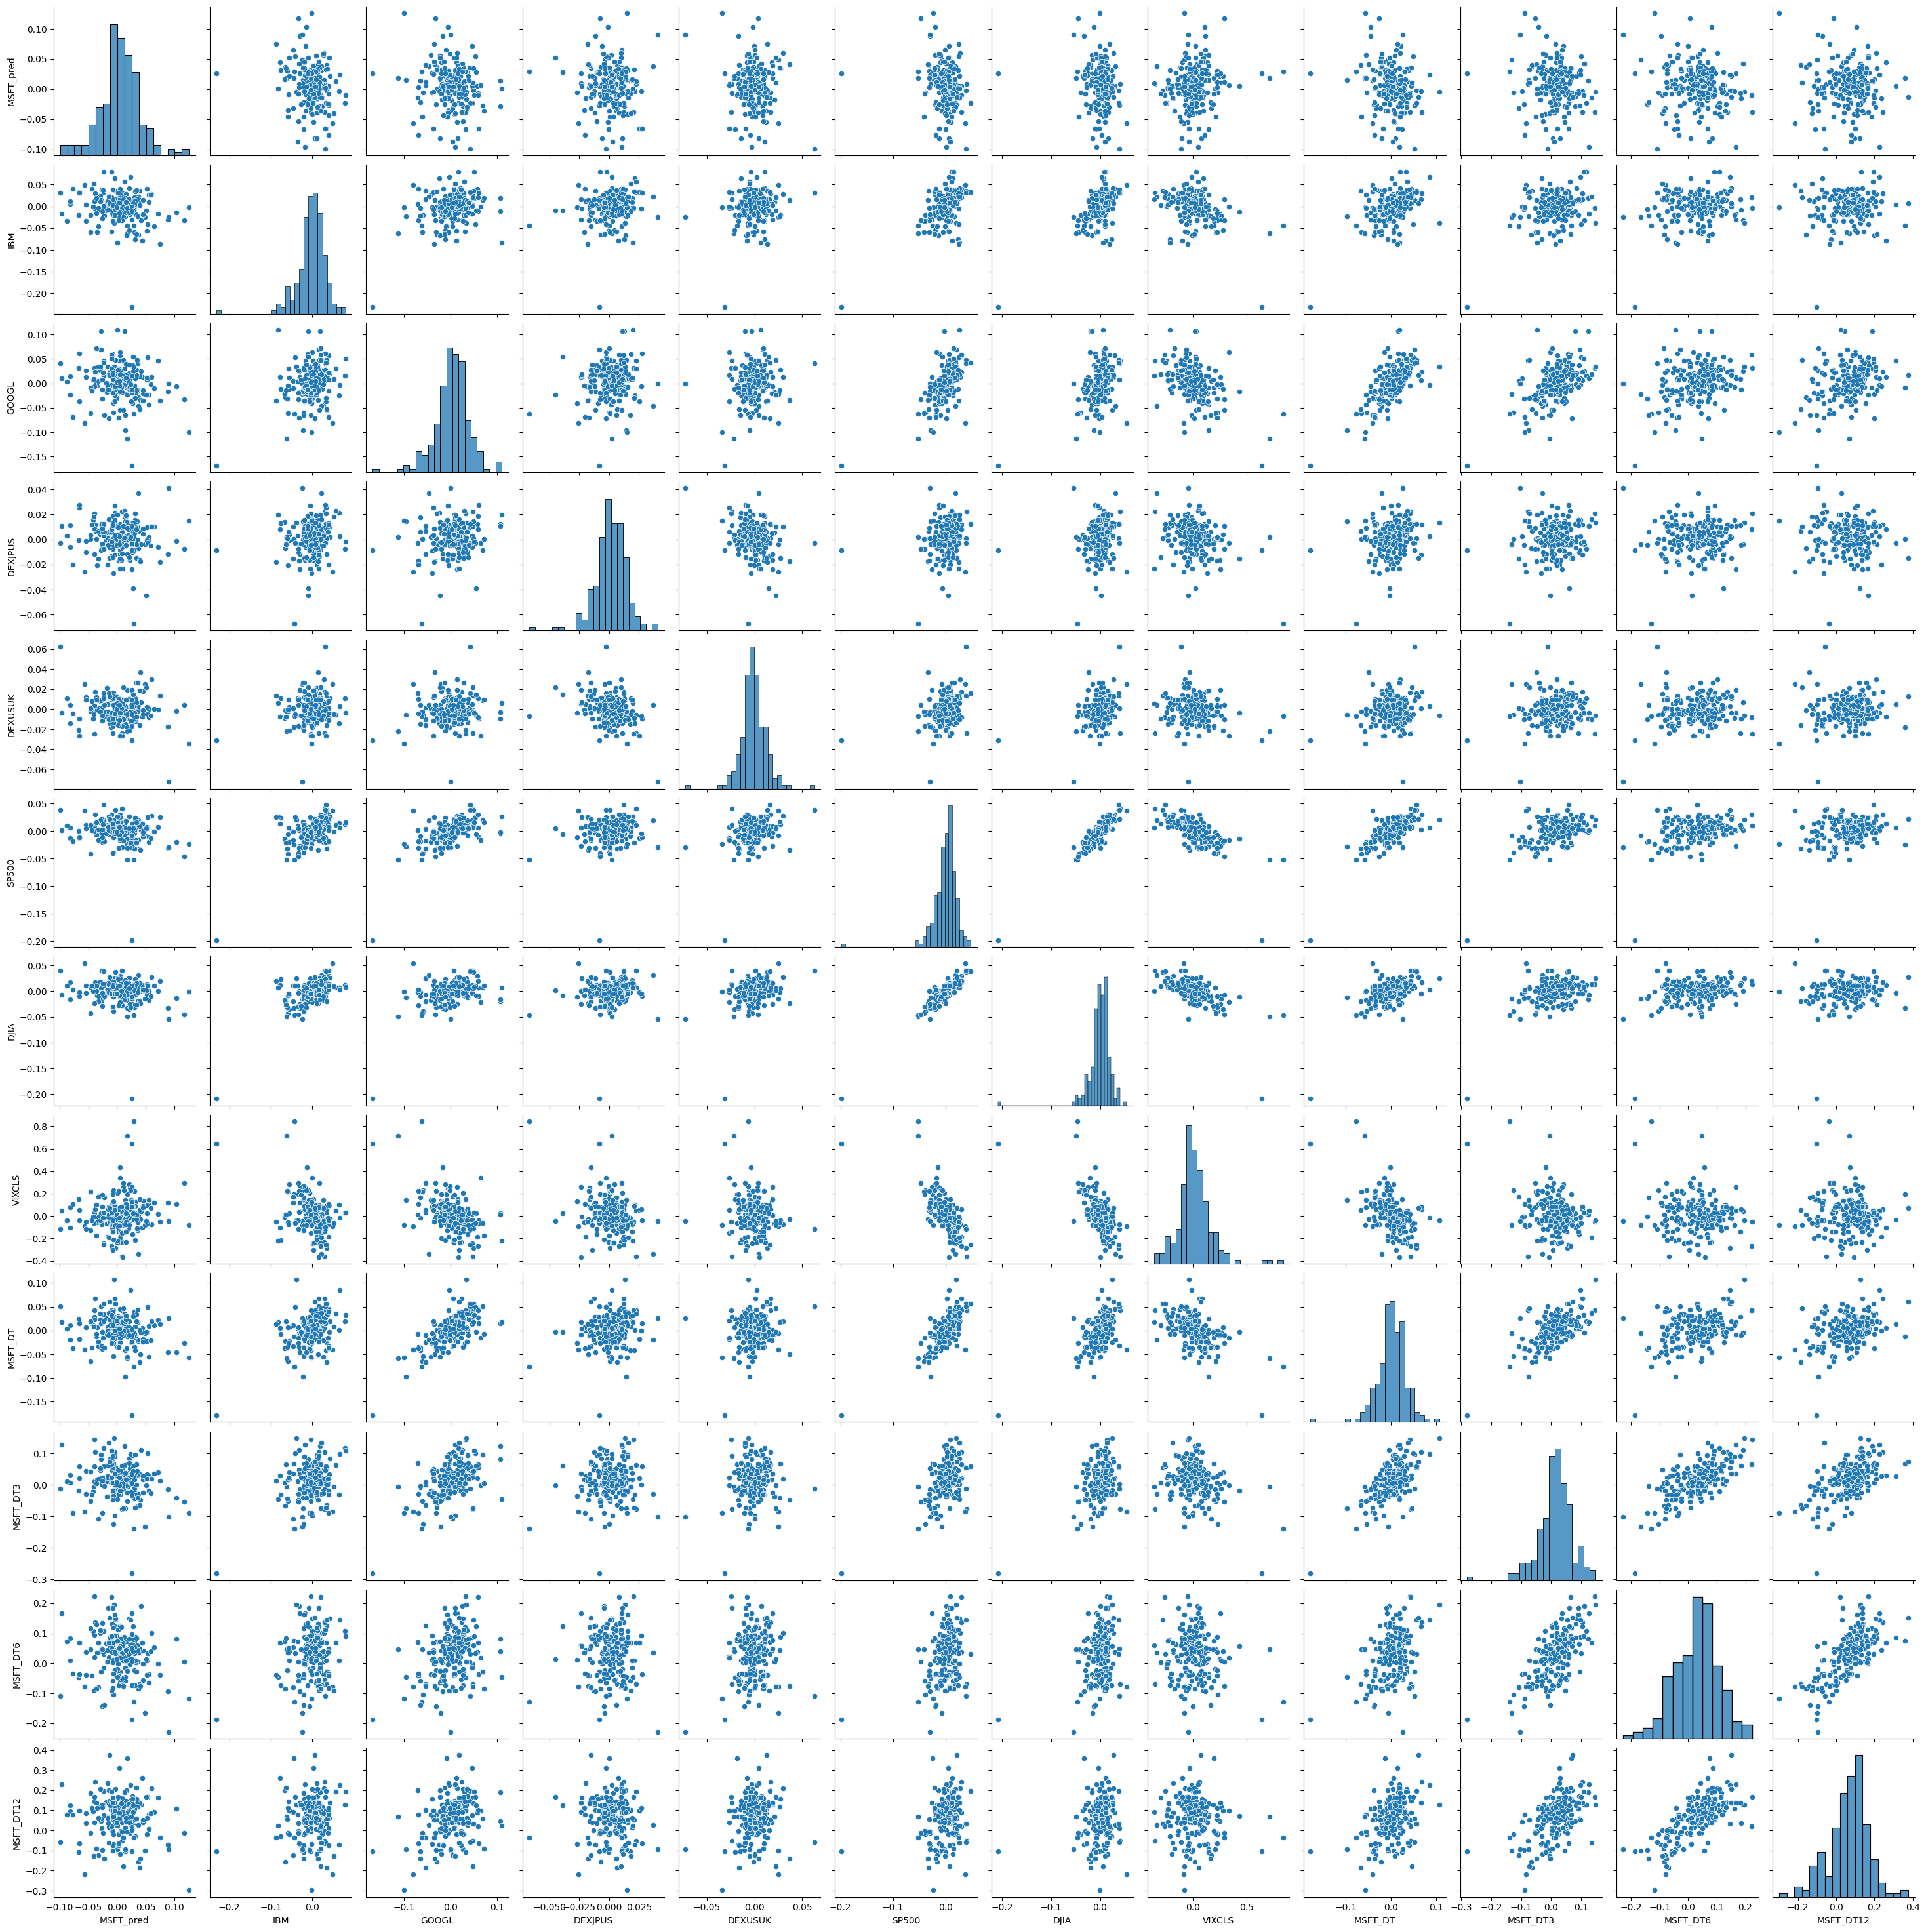

In [26]:
sns.pairplot(data.sample(200))
plt.show()

Fazendo a decomposição da serie temporal

<Figure size 2000x1000 with 0 Axes>

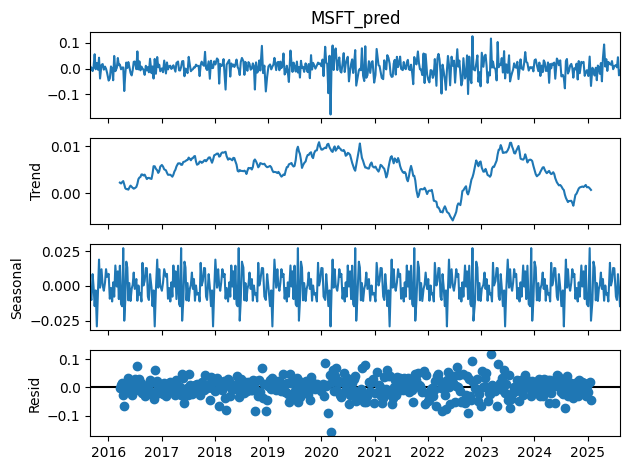

In [27]:

res = sm.tsa.seasonal_decompose(data['MSFT_pred'], model='additive', period=52)
plt.figure(figsize=(20,10))
res.plot()

plt.show()

Dividindo os dados de treino e teste  mas mantendo os dados em ordem visto que é uma série temporal.

In [28]:
train_size = int(len(data) * 0.8)

xtrain, xtest = X.iloc[:train_size,:].values, X.iloc[train_size:,:].values
ytrain, ytest = Y.iloc[:train_size].values, Y.iloc[train_size:].values


In [29]:
num_folds = 10
scoring   = 'neg_mean_squared_error'

In [37]:
models = [
    ('Linear Regression', LinearRegression()),
    ('Lasso Regression', Lasso()),
    ('ElasticNet Regression', ElasticNet()),
    ('KNN Regressor', KNeighborsRegressor()),
    ('CART Regressor', DecisionTreeRegressor()),
    ('SVR Regressor', SVR()),
    ('Random Forest Regressor', RandomForestRegressor()),
    ('Gradient Boosting Regressor', GradientBoostingRegressor()),
    ('Extra Trees Regressor', ExtraTreesRegressor()),
    ('AdaBoost Regressor', AdaBoostRegressor()),
    ('MLP Regressor', MLPRegressor(max_iter=500)), 
    ('Time Series Forest Regressor', TimeSeriesForestRegressor(n_estimators=100))   
]

In [38]:
names = []
kfold_result = []
test_result = []
train_result = []

In [39]:
from concurrent.futures import ThreadPoolExecutor, wait, as_completed, FIRST_COMPLETED,ALL_COMPLETED

In [40]:
def evaluate_model(name, model):
    global names, kfold_result, test_result, train_result
    

    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=42)
    
    cv_results = -1 * cross_val_score(model, xtrain, ytrain.ravel(), cv=kfold, scoring=scoring)
    
    # Treina o modelo
    res = model.fit(xtrain, ytrain.ravel())
    
    
    pred_test = res.predict(xtest)
    pred_train =res.predict(xtrain)
    mse_test = mean_squared_error(ytest.ravel(), pred_test)
    mse_train = mean_squared_error(ytrain.ravel(), pred_train)
    
    names.append(name)
    kfold_result.append(cv_results)
    test_result.append(mse_test)
    train_result.append(mse_train)

In [ ]:
with ThreadPoolExecutor(max_workers=4) as executor:
    futures = [executor.submit(evaluate_model, name, model) for name, model in models]


    # Aguarda a conclusão das tarefas
    done, not_done = wait(futures, timeout=600, return_when=ALL_COMPLETED)
    # Cancela 
    for f in not_done:
        f.cancel()

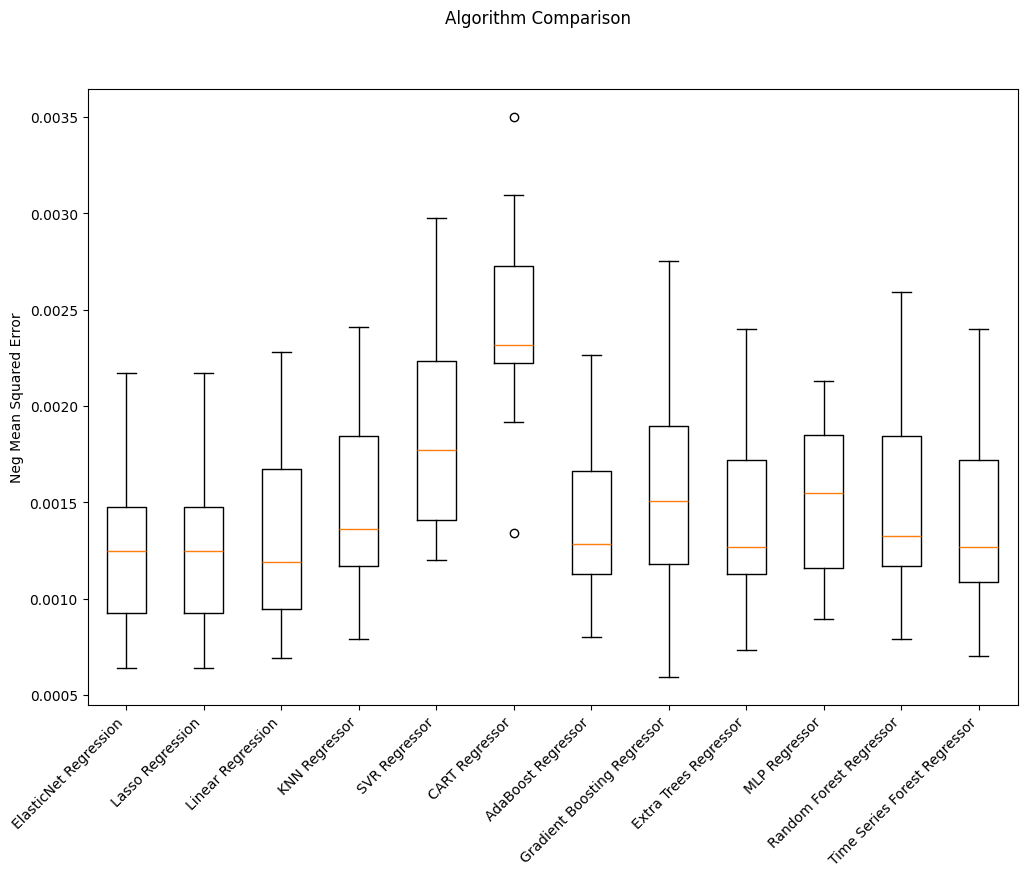

In [42]:
fig = plt.figure(figsize=(12,8))
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(kfold_result)
ax.set_xticklabels(names, rotation=45, ha='right')
plt.ylabel('Neg Mean Squared Error')
plt.show()

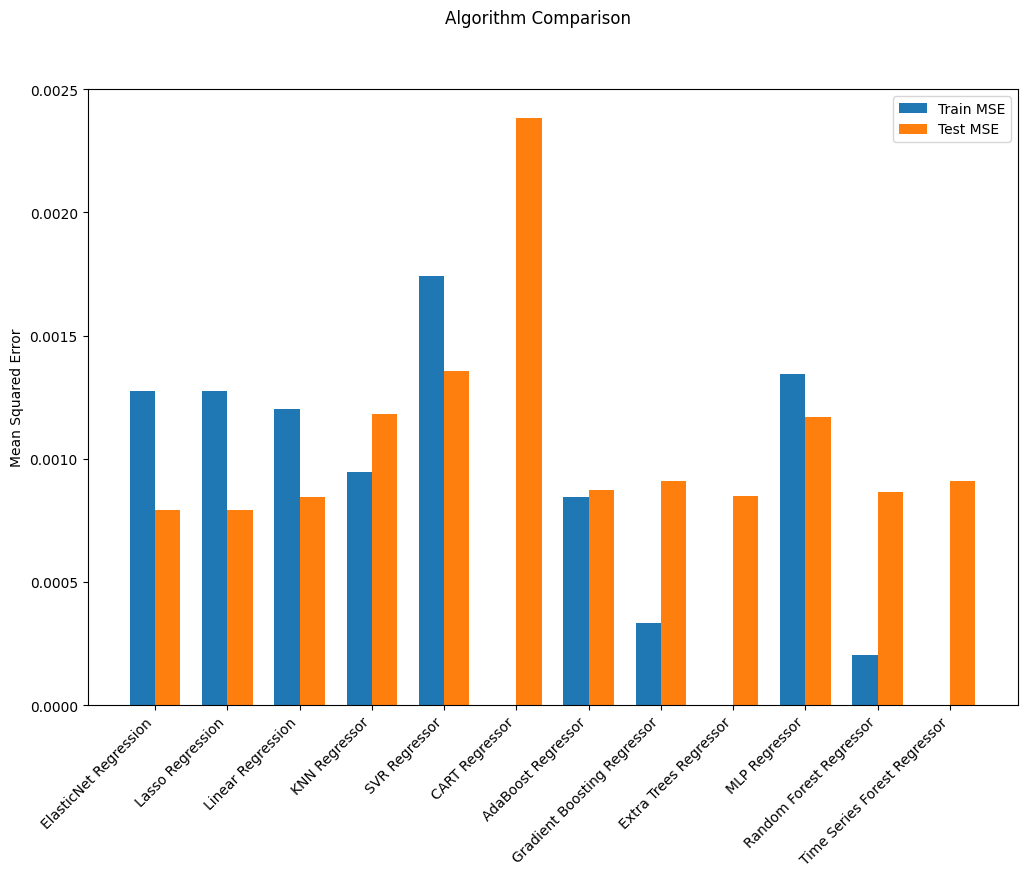

In [49]:
fig = plt.figure(figsize=(12,8))
fig.suptitle('Algorithm Comparison')
ind= np.arange(len(names)) # as posições das barras
width = 0.35 # a largura das barras

plt.bar(ind - width/2, train_result, width, label='Train MSE')
plt.bar(ind + width/2, test_result, width, label='Test MSE')
plt.ylabel('Mean Squared Error')
plt.xticks(ind, names, rotation=45, ha='right')
plt.legend()
plt.show()

#### ARIMAX

In [52]:
X_ARIMA = X.loc[:, ['GOOGL', 'IBM', 'DEXJPUS', 'DEXUSUK', 'SP500', 'DJIA', 'VIXCLS']]

xtrain_arima, xtest_arima = X_ARIMA.iloc[:train_size,:], X_ARIMA.iloc[train_size:,:]

In [55]:
arima = sm.tsa.ARIMA(endog=ytrain, exog=xtrain_arima, order=(1,0,0))
arima_fit = arima.fit()

c:\Users\mateu\Documents\Norton\Projetos GIT\livro-blueprints-de-aprendizado-de-maquina-e-cd-para-financas\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mateu\Documents\Norton\Projetos GIT\livro-blueprints-de-aprendizado-de-maquina-e-cd-para-financas\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mateu\Documents\Norton\Projetos GIT\livro-blueprints-de-aprendizado-de-maquina-e-cd-para-financas\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init

In [58]:
error_train_arima = mean_squared_error(ytrain.ravel(), arima_fit.fittedvalues)

In [59]:
pred_test_arima = arima_fit.predict(start=len(ytrain)-1, end=len(ytrain)+len(ytest)-1, exog=xtest_arima)[1:]

c:\Users\mateu\Documents\Norton\Projetos GIT\livro-blueprints-de-aprendizado-de-maquina-e-cd-para-financas\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\mateu\Documents\Norton\Projetos GIT\livro-blueprints-de-aprendizado-de-maquina-e-cd-para-financas\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [64]:
error_test_arima = mean_squared_error(ytest.ravel(), pred_test_arima)

In [65]:
error_test_arima, error_train_arima

(0.0007743691342092477, 0.0012314655667434195)

#### LSTM

In [67]:
# Comprimento do seq para LSTM
seq_len = 10

In [73]:
def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:(i + seq_len)])
        ys.append(y[i + seq_len])
    return np.array(Xs), np.array(ys)

In [74]:
xtrain_ltsm, ytrain_ltsm = create_sequences(xtrain, ytrain, seq_len)

In [75]:
xtest_ltsm, ytest_ltsm = create_sequences(xtest, ytest, seq_len)

In [76]:
xtrain_ltsm.shape

(368, 10, 11)

In [77]:
model = keras.models.Sequential([
    keras.layers.LSTM(50, activation='relu', return_sequences=True, input_shape=(seq_len, xtrain_ltsm.shape[2])),
    keras.layers.LSTM(50, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
])

c:\Users\mateu\Documents\Norton\Projetos GIT\livro-blueprints-de-aprendizado-de-maquina-e-cd-para-financas\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [81]:
model.compile(optimizer='adam', loss='mse')
history = model.fit(
    xtrain_ltsm, ytrain_ltsm, 
    epochs=100, 
    batch_size=72, 
    validation_data=(xtest_ltsm, ytest_ltsm)    ,
    shuffle=False,
    verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

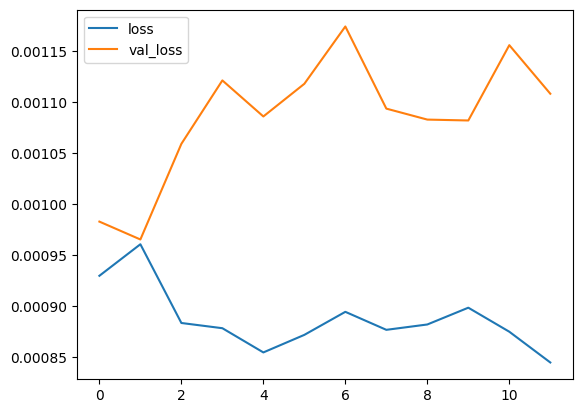

In [82]:
pd.DataFrame(history.history).plot()
plt.show()

In [83]:
error_train_lstm = mean_squared_error(ytrain_ltsm, model.predict(xtrain_ltsm))
error_test_lstm = mean_squared_error(ytest_ltsm, model.predict(xtest_ltsm))

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


In [84]:
test_result.append(error_test_arima)
test_result.append(error_test_lstm)
train_result.append(error_train_arima)
train_result.append(error_train_lstm)

In [85]:
names.append('ARIMA Regressor')
names.append('LSTM Regressor')

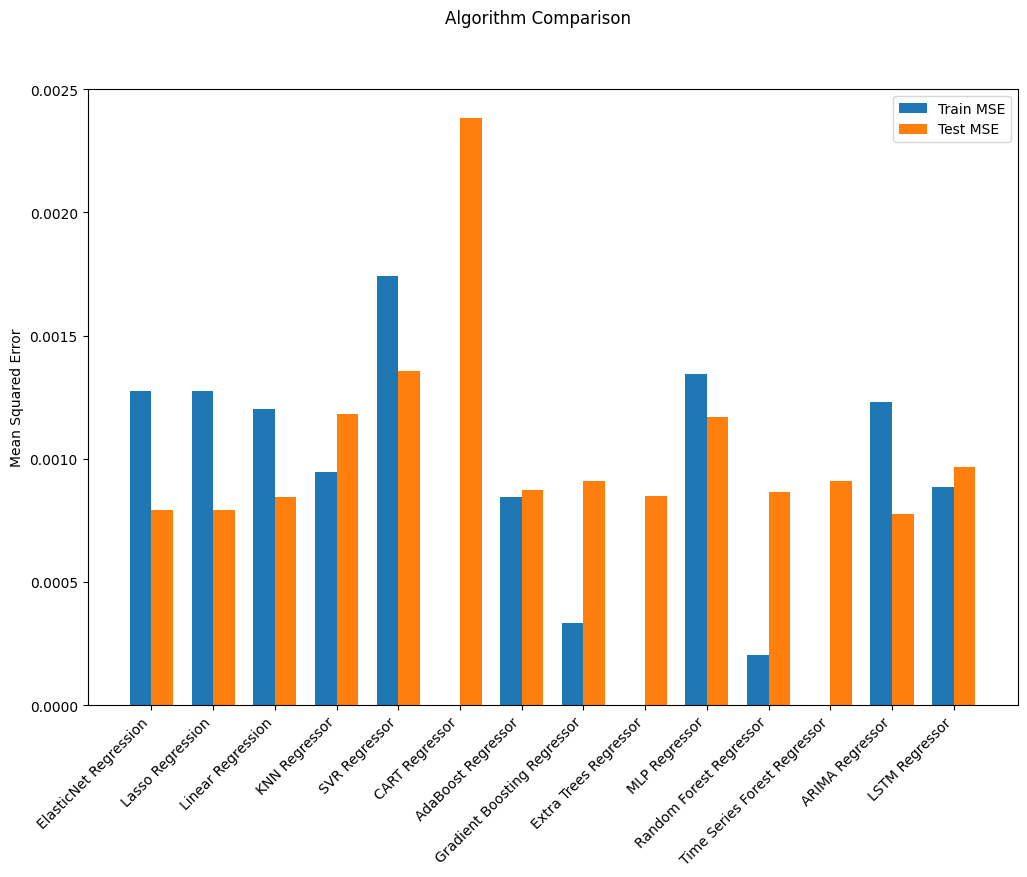

In [86]:
fig = plt.figure(figsize=(12,8))
fig.suptitle('Algorithm Comparison')
ind= np.arange(len(names)) # as posições das barras
width = 0.35 # a largura das barras
plt.bar(ind - width/2, train_result, width, label='Train MSE')
plt.bar(ind + width/2, test_result, width, label='Test MSE')
plt.ylabel('Mean Squared Error')
plt.xticks(ind, names, rotation=45, ha='right')
plt.legend()
plt.show()

Gridsearch para arima

In [89]:
def evaluate_arima(order):
    arima = sm.tsa.ARIMA(endog=ytrain, exog=xtrain_arima, order=order)
    arima_fit = arima.fit()
    
    return mean_squared_error(ytrain, arima_fit.fittedvalues) 

In [92]:
import warnings
warnings.filterwarnings('ignore')
def evaluate_models(max_p, max_d, max_q):
    best_score, best_cfg = float("inf"), None
    for p in range(max_p+1):
        for d in range(max_d+1):
            for q in range(max_q+1):
                order = (p,d,q)
                try:
                    mse = evaluate_arima(order)
                    if mse < best_score:
                        best_score, best_cfg = mse, order
                    print(f'ARIMA{order} MSE={mse:.4f}')
                except:
                    continue
    print(f'Best ARIMA{best_cfg} MSE={best_score:.4f}')
    return best_cfg

In [93]:
best_arima = evaluate_models(2, 1, 2)

ARIMA(0, 0, 0) MSE=0.0012
ARIMA(0, 0, 1) MSE=0.0012
ARIMA(0, 0, 2) MSE=0.0012
ARIMA(0, 1, 0) MSE=0.0022
ARIMA(0, 1, 1) MSE=0.0012
ARIMA(0, 1, 2) MSE=0.0013
ARIMA(1, 0, 0) MSE=0.0012
ARIMA(1, 0, 1) MSE=0.0012
ARIMA(1, 0, 2) MSE=0.0012
ARIMA(1, 1, 0) MSE=0.0019
ARIMA(1, 1, 1) MSE=0.0013
ARIMA(1, 1, 2) MSE=0.0012
ARIMA(2, 0, 0) MSE=0.0012
ARIMA(2, 0, 1) MSE=0.0012
ARIMA(2, 0, 2) MSE=0.0012
ARIMA(2, 1, 0) MSE=0.0017
ARIMA(2, 1, 1) MSE=0.0013
ARIMA(2, 1, 2) MSE=0.0012
Best ARIMA(2, 0, 1) MSE=0.0012


Resultados

In [94]:
best_arima = sm.tsa.ARIMA(endog=ytrain, exog=xtrain_arima, order=(2,1,2)).fit()


pred = best_arima.predict(start=len(ytrain)-1, end=len(ytrain)+len(ytest)-1, exog=xtest_arima)[1:]
error_test_arima = mean_squared_error(ytest.ravel(), pred)
mean_squared_error(ytest.ravel(), pred)

0.000778564712074046

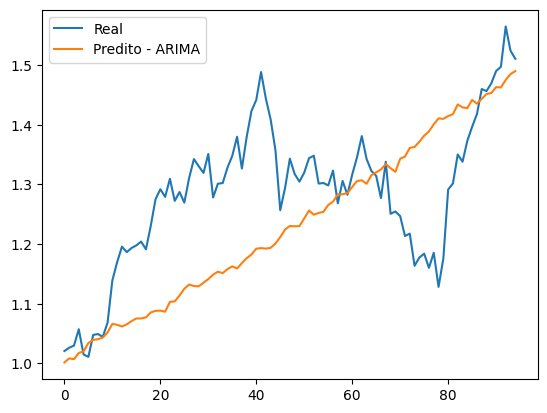

In [98]:

plt.plot(range(len(ytest)),np.exp(ytest).cumprod(), label='Real')
plt.plot(range(len(ytest)),np.exp(pred).cumprod(), label='Predito - ARIMA')
plt.legend()